# DESCRIPTIVE STATISTICS

## Task: Statistics & Probability

Task Breakdown

- Descriptive statistics (mean, variance, std dev)

- Probability distributions

- Hypothesis testing

- Correlation vs causation

## Load dataset

In [20]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
housing_data = pd.read_csv('cleaned_housing_prices.csv')

In [22]:
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_sqft
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1792.452830
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1367.187500
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1229.919679
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1628.666667
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1537.735849


## Descriptive statistics (mean, variance, std dev)

In [23]:
housing_stat = housing_data[['price', 'area', 'price_per_sqft']].agg(['mean', 'var', 'std']).round(2)

# display
housing_stat.style.set_caption("Table 1: Descriptive Statistics for Housing Dataset")

,price,area,price_per_sqft
mean,4766729.250000,5150.540000,993.330000
var,3498544355820.580078,4709512.060000,120087.910000
std,1870439.620000,2170.140000,346.540000


## Probability distributions

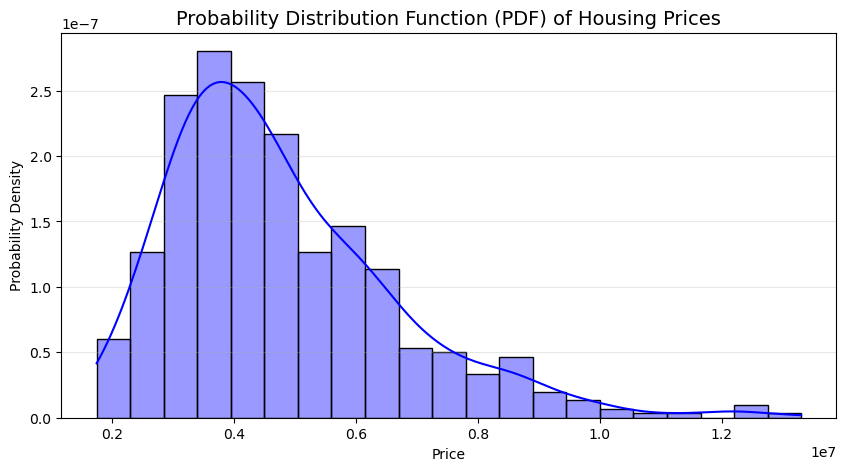

In [7]:
plt.figure(figsize=(10, 5))

# Plot the actual distribution of your prices
sns.histplot(housing_data['price'], kde=True, stat="density", color="blue", alpha=0.4)

plt.title('Probability Distribution Function (PDF) of Housing Prices', fontsize=14)
plt.xlabel('Price')
plt.ylabel('Probability Density')
plt.grid(axis='y', alpha=0.3)

plt.show()

right-hand skewness!

## What is the probability that a randomly selected house in our dataset costs more than 7,000,000?

In [8]:
# Calculate the Probability that housing Price is greater than  7,000,000
prob_expensive = (housing_data['price'] > 7000000).mean()

print(f"The empirical probability of a house costing more than 7M is: {prob_expensive:.2%}")

The empirical probability of a house costing more than 7M is: 11.74%


This proves that if an agent picks a house at random from this market, there is roughly an $11\%$ chance it will be a premium outlier. The other $88.26\%$ of the market sits comfortably below that $7\text{M}$ line.

## What is the probability of a house being priced between 3,000,000 and 5,000,000

In [9]:
mean_price = 4766729.25
std_price = 1870439.62

# Calculate probability using the normal distribution model
prob_between = stats.norm.cdf(5000000, mean_price, std_price) - stats.norm.cdf(3000000, mean_price, std_price)

print(f"The theoretical probability of a house being between 3M and 5M is: {prob_between:.2%}")

The theoretical probability of a house being between 3M and 5M is: 37.72%


This tells us that the $3\text{M}$ to $5\text{M}$ bracket is the absolute "sweet spot" or high-density core of your housing market. It represents the baseline volume where more than a third of the market lives.

# Hypothesis testing

**Null Hypothesis (Ho)**:The true mean price per sq ft of Preferred Areas is equal to Standard Areas. 

**Alternative Hypothesis (H1)**: The true mean price per sq ft of Preferred Areas is significantly different from Standard Areas).

In [12]:
# 1. Isolate the price_per_sqft for both groups
standard_area = housing_data[housing_data['prefarea'] == 'no']['price_per_sqft']
prime_area = housing_data[housing_data['prefarea'] == 'yes']['price_per_sqft']

# 2. Run Welch's t-test (equal_var=False because group sizes and variances differ)
t_stat, p_val = stats.ttest_ind(prime_area, standard_area, equal_var=False)

# 3. Format and print the results beautifully
print("--- Two-Sample t-Test Results ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}") # Prints in scientific notation if it's very small

--- Two-Sample t-Test Results ---
T-Statistic: 2.5183
P-Value: 1.2543e-02


P-value (0.0125) is less than 0.05. There is a statistical significance.

**reject the Null Hypothesis (Ho) and accept the Alternative Hypothesis (H1)**. 

# Correlation vs causation

# Plot the Targeted Correlation Matrix

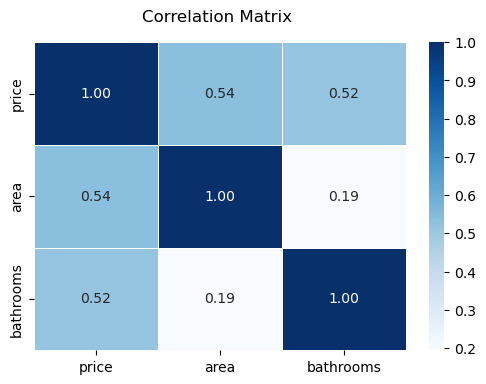

In [15]:
# Isolate the core variables
core_features = housing_data[['price', 'area', 'bathrooms']]

# Calculate the correlation matrix
correlation_matrix = core_features.corr()

# Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix ', fontsize=12, pad=15)
plt.show()

* **The Correlation (r = 0.54)**:  There is a moderate-to-strong positive linear relationship showing that as square footage increases, property price steadily climbs.

* **The Correlation (r = 0.52)**: There is a clear positive correlation indicating that properties with a higher number of bathrooms command significantly higher market prices.

Housing price data is also observational. Sellers only build extra bathrooms because the rest of the house is already large and luxurious. Therefore, bathrooms and price move together but we can't randomly isolate the bathrooms to prove they cause the price hike.

# Finding/Observation

* the average house price sits at 4,766,729.25, but the Standard Deviation is an incredibly high 1,870,439.62. In a perfectly balanced market, most homes sit right next to the average. Here, because the standard deviation is massive (nearly 40% of the mean value), it proves that individual home prices drift wildly away from the average.

  
*  the  probability calculation showed that there is a 37.72% probability of people randomly selected house falling between 3,000,000 and 5,000,000 but if an investor or real estate agency wants to target the highest volume of buyers,  price bracket is the absolute core of your market. More than a third of the entire housing ecosystem lives in this specific density window

*    the Two-Sample t-test evaluating Preferred Areas vs. Standard Areas yielded a T-Statistic of 2.5183 and a P-Value of 0.0125.The p-value (0.0125) is safely below the standard  significance threshold of 0.05, the  Null Hypothesis is reject. This proves mathematically that preferred locations command a genuinely higher price per square foot. The location premium isn't a random quirk or fluke of your sample data; it is a statistically verified market reality.

# Conculsion

Applying statistics and probability models to the housing dataset, the following was established :

*  The average house price is **4,766,729.25**. However, a massive standard deviation of **1,870,439.62** proves the market is highly volatile and skewed by luxury properties. 
*  While exactly **11.74%** of the market consists of luxury outliers priced above 7M, our continuous probability model shows a **37.72% probability** that a house falls between **3M and 5M**, making this bracket the high-volume core of the market.
*  the Two-Sample t-test yielded a p-value of **0.0125** (p < 0.05) which  is statistically significant making the null hypothesis rejected  and prove that preferred locations (prefarea) command a genuinely higher price per square foot.
*  Higher square footage (area, r = 0.54) and bathroom count (bathrooms, r = 0.52) are strongly correlated with price. However, these are proxy metrics; the **overall scale and luxury tier** of the house is the true causal driver of value, not individual plumbing fixtures in isolation.